In [ ]:
%pip install torchmetrics
!pip install torchinfo

In [2]:
import os
import random
import torch
import numpy as np
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, random_split, Subset
import torch.nn as nn
import torch.nn.functional as F
from torchmetrics.classification import MulticlassAccuracy
import torch.optim as optim
from tqdm import tqdm
import time
from torchinfo import summary
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset

In [ ]:
# Load dataset
seed = 42
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
val_ratio = 0.1
generator = torch.Generator().manual_seed(seed)
use_reduced_data = True

transform = transforms.Compose([
    transforms.RandomResizedCrop((32, 32), scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation((-30, 30)),
    # transforms.ColorJitter(),
    transforms.RandAugment(num_ops=2, magnitude=7),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transformTest = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

CIFAR10Dataset = torchvision.datasets.CIFAR10(root='.', download=True)
full_train_dataset = torchvision.datasets.CIFAR10(root='.', train=True, download=True, transform=None)
test_dataset = torchvision.datasets.CIFAR10(root='.', train=False, download=True, transform=transformTest)

if use_reduced_data:
    total_reduced_size = 10000
    selected_indices = torch.randperm(len(full_train_dataset), generator=generator)[:total_reduced_size]
else:
    selected_indices = torch.arange(len(full_train_dataset))

val_size = int(len(selected_indices) * val_ratio)
train_size = len(selected_indices) - val_size
train_indices, val_indices = random_split(selected_indices, [train_size, val_size], generator=generator)


train_dataset = Subset(
    torchvision.datasets.CIFAR10(root='.', train=True, download=False, transform=transform),
    train_indices.indices
)

val_dataset = Subset(
    torchvision.datasets.CIFAR10(root='.', train=True, download=False, transform=transformTest),
    val_indices.indices
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=os.cpu_count())
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=os.cpu_count())
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=os.cpu_count())

# Pretrained model ResNet50

In [ ]:
import torch.nn as nn
from torchvision.models import resnet50

def get_resnet50(num_classes=10):
    model = resnet50(pretrained=True)

    # Adjust first conv and maxpool for CIFAR-10 input size
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()

    # Freeze all layers initially
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze last half: layer3, layer4, and fc
    for name, param in model.named_parameters():
        if "layer3" in name or "layer4" in name or "fc" in name:
            param.requires_grad = True

    # Replace final classification layer
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model
resnet50_model = get_resnet50()
resnet50_model.to(device)

# Small CNN

In [5]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SmallCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8*8*64, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)
student = SmallCNN().to(device)

# Train and Validation

In [6]:
def train(model, train_loader, val_loader, epochs, learning_rate, device):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    model.to(device)
    results = []
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        start_time = time.time()

        for inputs, labels in (train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        val_acc, val_loss = validation(model, val_loader, device, show_metrics=False)
        scheduler.step()
        print(f"Epoch {epoch+1}/{epochs}({time.time() - start_time:.2f}s)  - accuracy: {train_acc:.4f}  - loss: {train_loss:.4f}  - val_accuracy: {val_acc:.4f}  - val_loss: {val_loss:.4f}")
        results.append([train_acc, train_loss, val_acc, val_loss])
    return results

def validation(model, test_loader, device, show_metrics=True):
    metric = MulticlassAccuracy(num_classes=10).to(device)
    model.eval()
    model.to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    total_loss = 0.0

    with torch.no_grad():
        for inputs, labels in (test_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            metric.update(outputs, labels)
            total_loss += loss.item()

    accuracy_val = metric.compute().item()
    avg_loss = total_loss / len(test_loader)

    if show_metrics:
        print(f"Validation Accuracy: {accuracy_val:.4f} Loss: {avg_loss:.4f}")
    return accuracy_val, avg_loss


def train_knowledge_distillation(teacher, student, train_loader, val_loader, epochs, learning_rate, T, alpha, device):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(student.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    teacher.eval()  # Teacher set to evaluation mode
    student.train() # Student to train mode

    results = []

    for epoch in range(epochs):
        running_loss, correct, total = 0.0, 0, 0
        start_time = time.time()
        for inputs, labels in (train_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.no_grad():
                teacher_logits = teacher(inputs)
            student_logits = student(inputs)

            label_loss = criterion(student_logits, labels)
            soft_prob = nn.functional.log_softmax(student_logits / T, dim=-1)
            soft_targets = nn.functional.softmax(teacher_logits / T, dim=-1)
            soft_targets_loss = F.kl_div(soft_prob, soft_targets, reduction='batchmean') * (T ** 2)
            loss = alpha * soft_targets_loss + (1 - alpha) * label_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(student_logits, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        val_acc, val_loss = validation(student, val_loader, device, show_metrics=False)
        scheduler.step()
        print(f"Epoch {epoch+1}/{epochs}({time.time() - start_time:.2f}s) - accuracy: {train_acc:.4f}  - loss: {train_loss:.4f}  - val_accuracy: {val_acc:.4f}  - val_loss: {val_loss:.4f}")
        results.append([train_acc, train_loss, val_acc, val_loss])
    return results


# Train ResNet50

In [7]:
epochs = 30
learning_rate = 1e-3
history_resnet50 = train(resnet50_model, train_loader, val_loader, epochs, learning_rate, device)
validation(resnet50_model, test_loader, device)

Epoch 1/30(21.15s)  - accuracy: 0.3863  - loss: 1.8432  - val_accuracy: 0.5207  - val_loss: 1.7401
Epoch 2/30(19.39s)  - accuracy: 0.5154  - loss: 1.5830  - val_accuracy: 0.5883  - val_loss: 1.5177
Epoch 3/30(20.02s)  - accuracy: 0.5722  - loss: 1.4527  - val_accuracy: 0.6667  - val_loss: 1.3271
Epoch 4/30(20.71s)  - accuracy: 0.6000  - loss: 1.3996  - val_accuracy: 0.6526  - val_loss: 1.2823
Epoch 5/30(21.24s)  - accuracy: 0.6239  - loss: 1.3405  - val_accuracy: 0.6704  - val_loss: 1.2225
Epoch 6/30(20.81s)  - accuracy: 0.6510  - loss: 1.2948  - val_accuracy: 0.7018  - val_loss: 1.1439
Epoch 7/30(20.62s)  - accuracy: 0.6698  - loss: 1.2479  - val_accuracy: 0.7117  - val_loss: 1.1819
Epoch 8/30(20.63s)  - accuracy: 0.6883  - loss: 1.2148  - val_accuracy: 0.7049  - val_loss: 1.1613
Epoch 9/30(20.78s)  - accuracy: 0.7047  - loss: 1.1788  - val_accuracy: 0.7400  - val_loss: 1.0992
Epoch 10/30(20.69s)  - accuracy: 0.7184  - loss: 1.1493  - val_accuracy: 0.7662  - val_loss: 1.0586
Epoch 11/

(0.8353999853134155, 0.8976279208614568)

# Scratch Student training

In [8]:
scratch_student = SmallCNN().to(device)
history_scratch = train(scratch_student, train_loader, val_loader, epochs, learning_rate, device)
validation(scratch_student, test_loader, device)

Epoch 1/30(8.37s)  - accuracy: 0.3271  - loss: 1.9517  - val_accuracy: 0.4256  - val_loss: 1.7168
Epoch 2/30(7.82s)  - accuracy: 0.4067  - loss: 1.7764  - val_accuracy: 0.4721  - val_loss: 1.6311
Epoch 3/30(8.78s)  - accuracy: 0.4380  - loss: 1.7030  - val_accuracy: 0.5058  - val_loss: 1.5856
Epoch 4/30(8.09s)  - accuracy: 0.4623  - loss: 1.6589  - val_accuracy: 0.5607  - val_loss: 1.4757
Epoch 5/30(8.22s)  - accuracy: 0.4849  - loss: 1.6202  - val_accuracy: 0.5664  - val_loss: 1.4695
Epoch 6/30(8.68s)  - accuracy: 0.4931  - loss: 1.5974  - val_accuracy: 0.5496  - val_loss: 1.4568
Epoch 7/30(7.59s)  - accuracy: 0.5089  - loss: 1.5647  - val_accuracy: 0.5851  - val_loss: 1.4164
Epoch 8/30(8.59s)  - accuracy: 0.5251  - loss: 1.5295  - val_accuracy: 0.5964  - val_loss: 1.3713
Epoch 9/30(8.55s)  - accuracy: 0.5463  - loss: 1.5065  - val_accuracy: 0.6147  - val_loss: 1.3442
Epoch 10/30(7.54s)  - accuracy: 0.5563  - loss: 1.4877  - val_accuracy: 0.6061  - val_loss: 1.3679
Epoch 11/30(8.69s) 

(0.6908999681472778, 1.1999445941038192)

# Knowledge Distillation

In [12]:
T, alpha = 4, 0.8

history_kd = train_knowledge_distillation(resnet50_model, student, train_loader, val_loader, epochs, learning_rate, T=T, alpha=alpha, device=device)
validation(student, test_loader, device)

Epoch 1/30(11.10s) - accuracy: 0.5244  - loss: 1.0301  - val_accuracy: 0.6418  - val_loss: 1.3359
Epoch 2/30(10.87s) - accuracy: 0.5618  - loss: 0.9469  - val_accuracy: 0.6388  - val_loss: 1.3202
Epoch 3/30(10.90s) - accuracy: 0.5933  - loss: 0.8749  - val_accuracy: 0.6700  - val_loss: 1.2613
Epoch 4/30(10.91s) - accuracy: 0.6071  - loss: 0.8359  - val_accuracy: 0.6722  - val_loss: 1.2531
Epoch 5/30(10.94s) - accuracy: 0.6181  - loss: 0.8288  - val_accuracy: 0.6702  - val_loss: 1.2525
Epoch 6/30(10.07s) - accuracy: 0.6290  - loss: 0.7887  - val_accuracy: 0.6846  - val_loss: 1.2507
Epoch 7/30(11.09s) - accuracy: 0.6366  - loss: 0.7888  - val_accuracy: 0.6742  - val_loss: 1.2251
Epoch 8/30(11.20s) - accuracy: 0.6466  - loss: 0.7566  - val_accuracy: 0.6901  - val_loss: 1.2635
Epoch 9/30(10.79s) - accuracy: 0.6532  - loss: 0.7510  - val_accuracy: 0.6811  - val_loss: 1.2308
Epoch 10/30(11.01s) - accuracy: 0.6649  - loss: 0.7287  - val_accuracy: 0.6849  - val_loss: 1.2322
Epoch 11/30(11.04s)

(0.7287999987602234, 1.1366559969391792)

In [9]:
import matplotlib.pyplot as plt
def plot_history(history, title):
    # Unpack the history
    train_acc = [row[0] for row in history]
    train_loss = [row[1] for row in history]
    val_acc   = [row[2] for row in history]
    val_loss  = [row[3] for row in history]
    epochs = range(1, len(history) + 1)

    # Plotting
    plt.figure(figsize=(12, 5))

    # Subplot 1: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_acc, label='Train Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()
    plt.grid(True)

    # Subplot 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss over Epochs')
    plt.legend()
    plt.grid(True)
    plt.suptitle(f'{title}', fontsize=16)
    plt.tight_layout()
    plt.show()


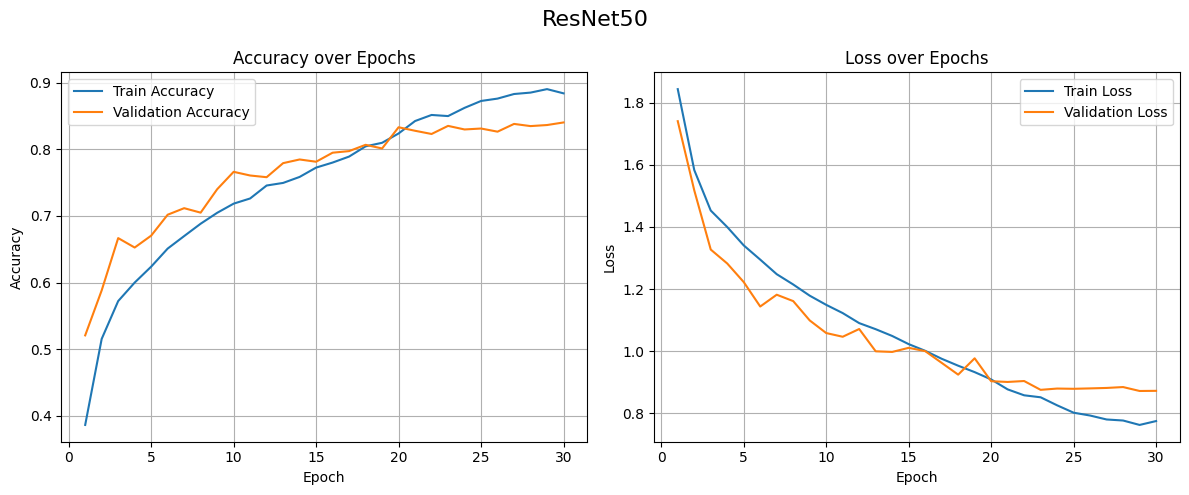

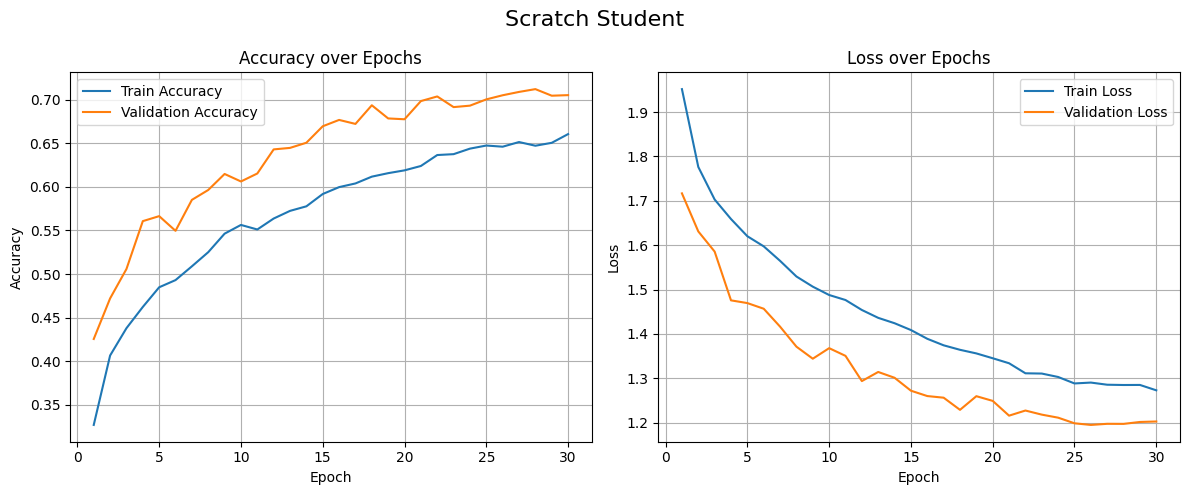

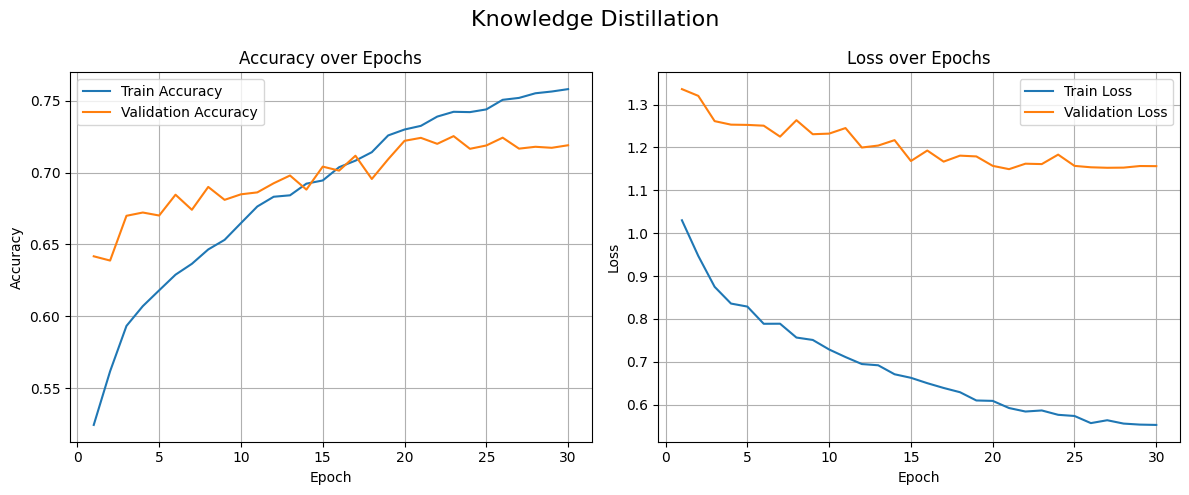

In [13]:
plot_history(history_resnet50, 'ResNet50')
plot_history(history_scratch, 'Scratch Student')
plot_history(history_kd, 'Knowledge Distillation')